<a href="https://colab.research.google.com/github/musowjanya/Datascience-Project/blob/main/L3T3_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Dataset .csv")

print(df.columns)
print(df.head())

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chin

In [3]:
# Drop missing ratings
df = df.dropna(subset=["Aggregate rating"])

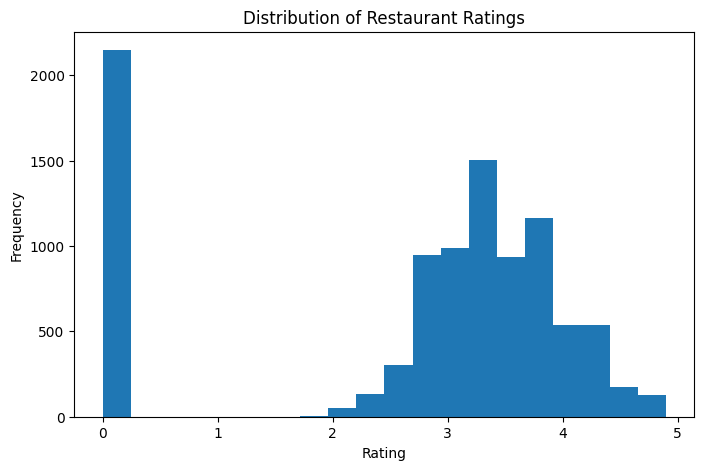

In [4]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["Aggregate rating"], bins=20)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

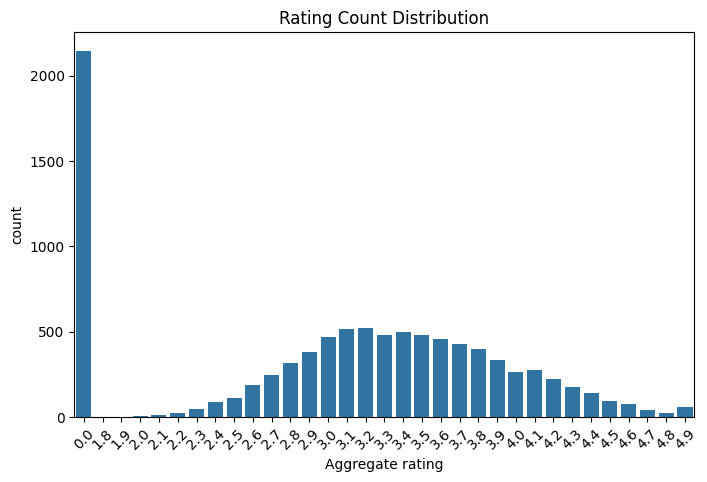

In [5]:
# Count plot (bar)
plt.figure(figsize=(8,5))
sns.countplot(x="Aggregate rating", data=df)
plt.title("Rating Count Distribution")
plt.xticks(rotation=45)
plt.show()

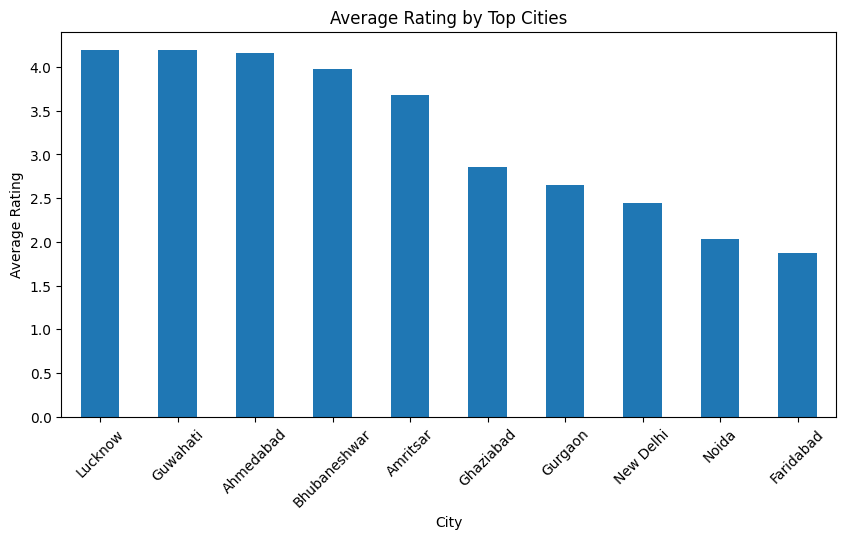

In [6]:
top_cities = df["City"].value_counts().head(10).index
city_df = df[df["City"].isin(top_cities)]

avg_city_rating = city_df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_city_rating.plot(kind='bar')
plt.title("Average Rating by Top Cities")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

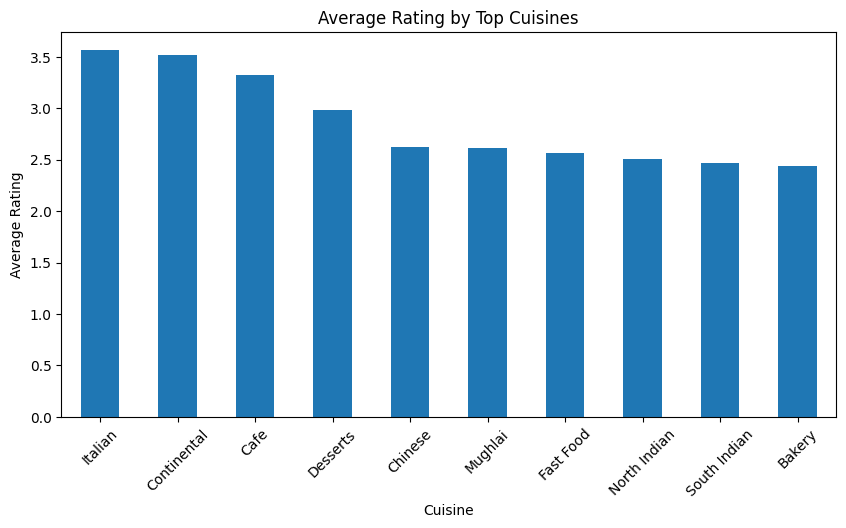

In [7]:
# Split cuisines
df["Cuisines"] = df["Cuisines"].fillna("Unknown").str.split(", ")
df_exploded = df.explode("Cuisines")

top_cuisines = df_exploded["Cuisines"].value_counts().head(10).index
cuisine_df = df_exploded[df_exploded["Cuisines"].isin(top_cuisines)]

avg_cuisine_rating = cuisine_df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_cuisine_rating.plot(kind='bar')
plt.title("Average Rating by Top Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

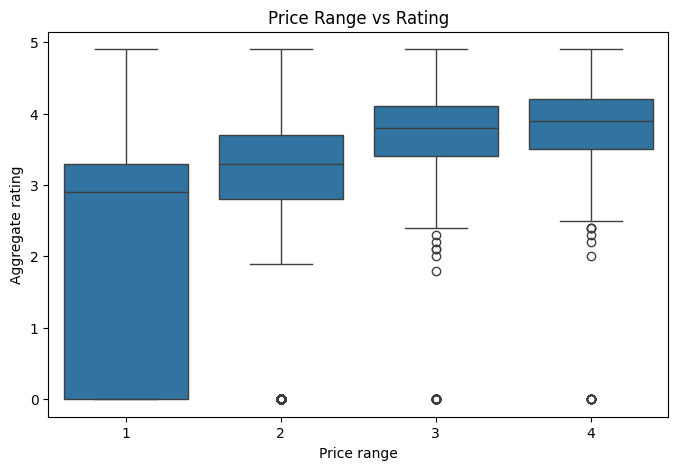

In [8]:
# Price Range vs Rating
plt.figure(figsize=(8,5))
sns.boxplot(x="Price range", y="Aggregate rating", data=df)
plt.title("Price Range vs Rating")
plt.show()

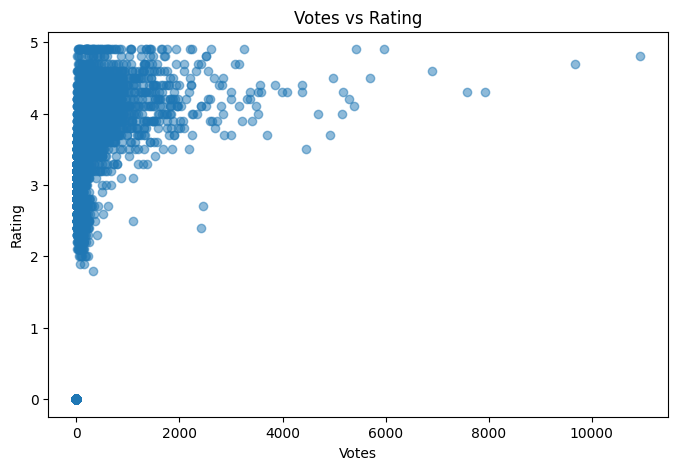

In [9]:
# Votes vs Rating
plt.figure(figsize=(8,5))
plt.scatter(df["Votes"], df["Aggregate rating"], alpha=0.5)
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

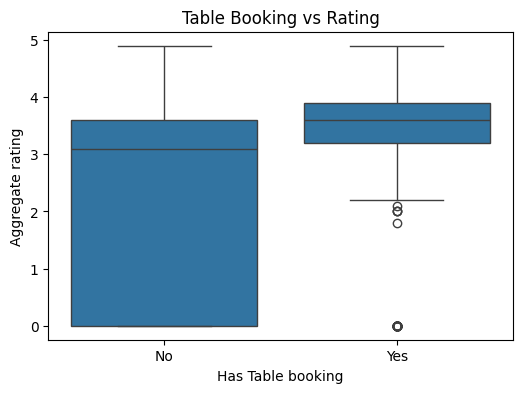

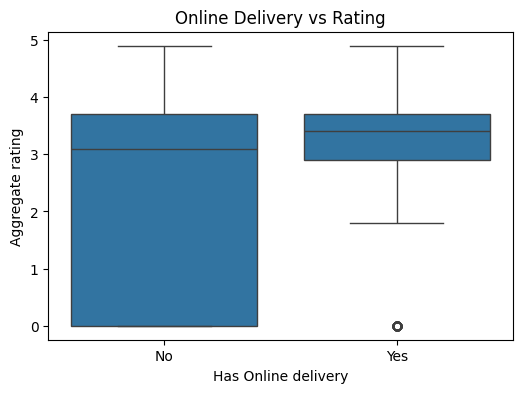

In [10]:
# Table Booking vs Rating
df["Has Table booking"] = df["Has Table booking"].map({"Yes": 1, "No": 0})

plt.figure(figsize=(6,4))
sns.boxplot(x="Has Table booking", y="Aggregate rating", data=df)
plt.xticks([0,1], ["No", "Yes"])
plt.title("Table Booking vs Rating")
plt.show()

# Online Delivery vs Rating
df["Has Online delivery"] = df["Has Online delivery"].map({"Yes": 1, "No": 0})

plt.figure(figsize=(6,4))
sns.boxplot(x="Has Online delivery", y="Aggregate rating", data=df)
plt.xticks([0,1], ["No", "Yes"])
plt.title("Online Delivery vs Rating")
plt.show()